RL policy mean reward: -10.781705340147019
Always continue mean reward: -19.242754358053208
Threshold policy mean reward: -19.39263498187065
Our learned policy does best that the treshold policy and always continue policy !


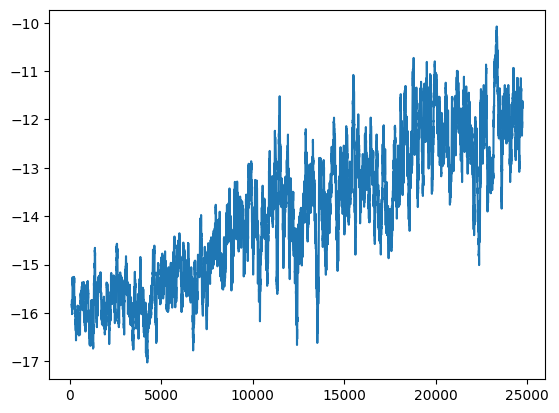

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from evaluate_policy import main
import numpy as np

#Plotting the learning curve

df = pd.read_csv("/Users/nelsonrouxdebezieux/Documents/industrial_agent/artifacts/monitor.csv")
plt.plot(pd.Series(df.index[1:]).rolling(window=100).mean())

res = main()
unique, counts = np.unique(res["action_list"], return_counts=True)

np.asarray((unique, counts)).T

print("Our learned policy does best that the treshold policy and always continue policy !")

Text(0.5, 0, 'True risk')

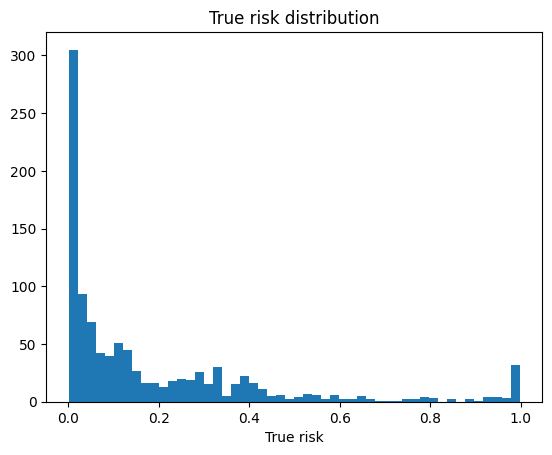

In [2]:
plt.hist(res["true_risk_list"], bins=50);
plt.title("True risk distribution")
plt.xlabel("True risk")

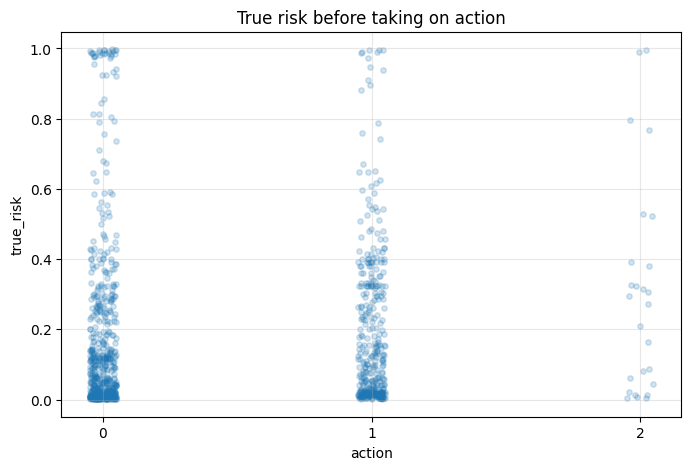

In [3]:
x = np.array(res["action_list"])[1:]
y = np.array(res["true_risk_list"])[:len(res["action_list"])-1]

# petit bruit horizontal
x_jitter = x + np.random.uniform(-0.05, 0.05, size=len(x))

plt.figure(figsize=(8, 5))
plt.scatter(x_jitter, y, alpha=0.2, s=15)
plt.xticks([0, 1, 2])
plt.xlabel("action")
plt.ylabel("true_risk")
plt.title("True risk before taking on action")
plt.grid(alpha=0.3)
plt.show()

Text(0, 0.5, 'Uncertainty')

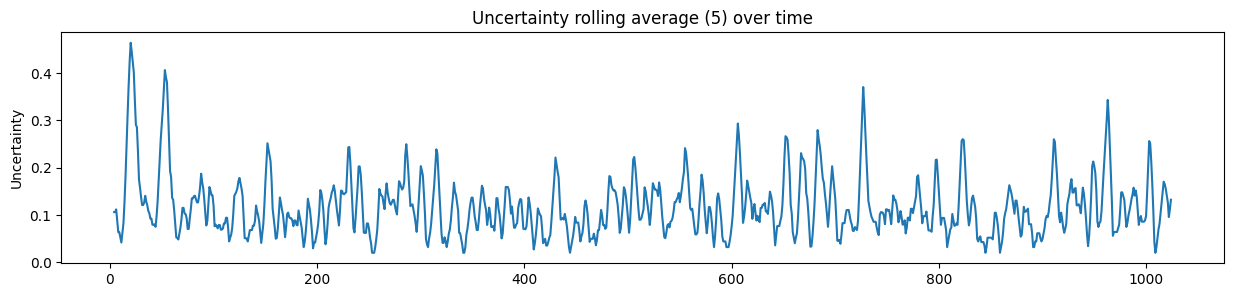

In [4]:
### Plotting uncertainty 

pd.Series(res["uncertainty_list"]).value_counts()
u = pd.Series(res["uncertainty_list"]).rolling(5).mean()
plt.figure(figsize=(15,3))
plt.plot(np.arange(len(u)), u)
plt.title("Uncertainty rolling average (5) over time")
plt.ylabel("Uncertainty")

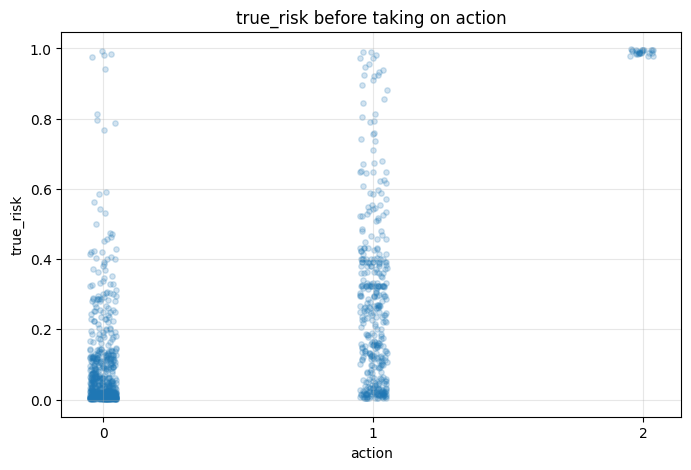

We are very happy to have learned a policy where consistent with the partially observed true risk ! 


In [5]:
#Plotting true risk before action

x = np.array(res["action_list"])
y = np.array(res["true_risk_list"])
x_jitter = x + np.random.uniform(-0.05, 0.05, size=len(x))

plt.figure(figsize=(8, 5))
plt.scatter(x_jitter, y, alpha=0.2, s=15)
plt.xticks([0, 1, 2])
plt.xlabel("action")
plt.ylabel("true_risk")
plt.title("true_risk before taking on action")
plt.grid(alpha=0.3)
plt.show()

print("We are very happy to have learned a policy where consistent with the partially observed true risk ! ")

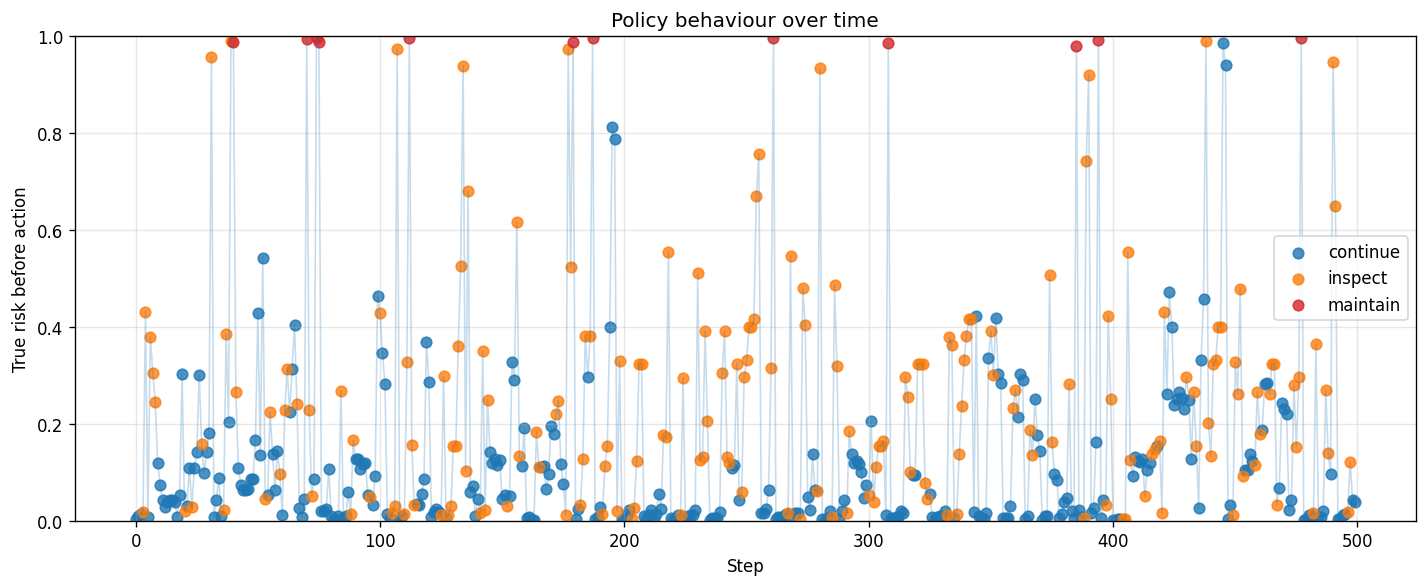

The sample policy path is quite consistent. 
When the partially obsevered true risk is too high, its maintains.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

actions = np.array(res["action_list"])[:500]
uncertainty = np.array(res["true_risk_list"])[:500]   # ou uncertainty_list[:-1]
steps = np.arange(len(actions))

action_labels = {
    0: "continue",
    1: "inspect",
    2: "maintain"
}

action_colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:red"
}

plt.figure(figsize=(12, 5), dpi=120)

# ligne de fond pour voir la dynamique
plt.plot(steps, uncertainty, alpha=0.25, linewidth=1)

# points colorés par action
for a in [0, 1, 2]:
    mask = actions == a
    plt.scatter(
        steps[mask],
        uncertainty[mask],
        s=40,
        alpha=0.8,
        label=action_labels[a],
        color=action_colors[a]
    )

plt.xlabel("Step")
plt.ylabel("True risk before action")
plt.title("Policy behaviour over time")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


print("The sample policy path is quite consistent. \nWhen the partially obsevered true risk is too high, its maintains.")

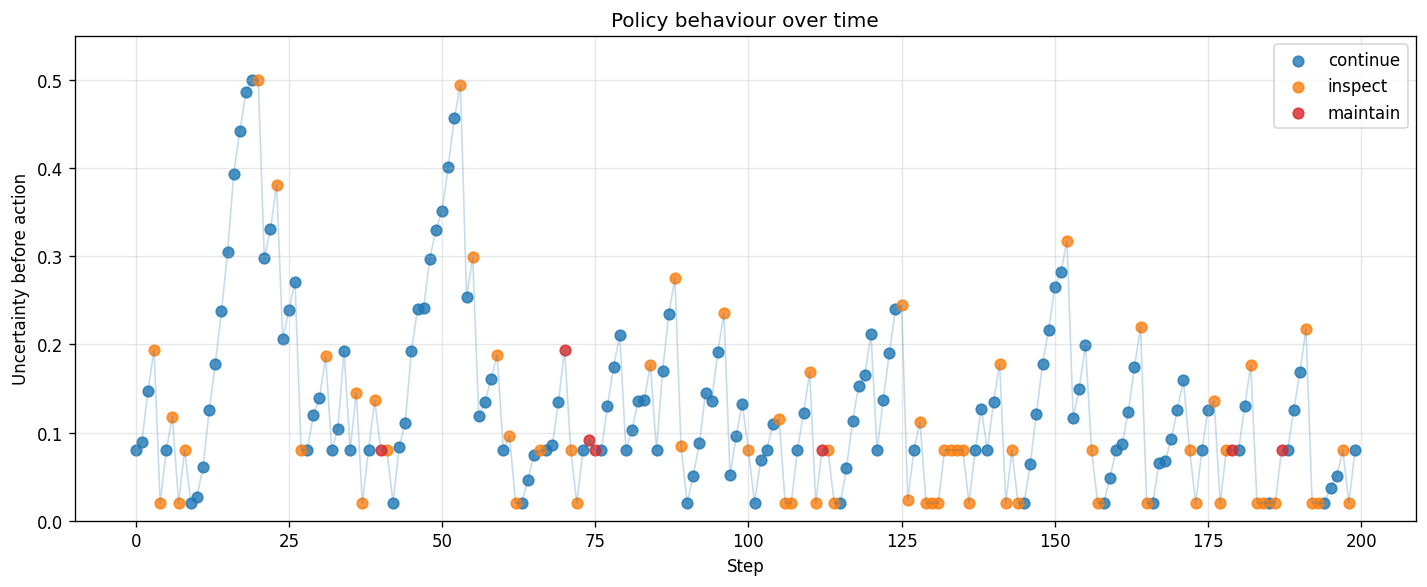

In [7]:
import numpy as np
import matplotlib.pyplot as plt

actions = np.array(res["action_list"])[:200]
uncertainty = np.array(res["uncertainty_list"])[:200]   # ou uncertainty_list[:-1]
steps = np.arange(len(actions))

action_labels = {
    0: "continue",
    1: "inspect",
    2: "maintain"
}

action_colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:red"
}

plt.figure(figsize=(12, 5), dpi=120)

# ligne de fond pour voir la dynamique
plt.plot(steps, uncertainty, alpha=0.25, linewidth=1)

# points colorés par action
for a in [0, 1, 2]:
    mask = actions == a
    plt.scatter(
        steps[mask],
        uncertainty[mask],
        s=40,
        alpha=0.8,
        label=action_labels[a],
        color=action_colors[a]
    )

plt.xlabel("Step")
plt.ylabel("Uncertainty before action")
plt.title("Policy behaviour over time")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0, 0.55)
plt.tight_layout()
plt.show()
